In [1]:
from AlphaZero import AlphaZero
from model import PruneModel
from prune_game import PruneGame
from evaluation import evaluate_current_model
from mcts import MCTS
args = {
    # import relativi a modelli e dati
    "model_name" : "distilgpt2",
    "name_dataset" : "wikitext",
    "device": "mps",

    # target di sparsity
    "target_sparsity" : 0.2,

    # iper params per Alphazero
    "num_episodes": 100,
    "num_self_iteration" : 20,
    "num_epochs" : 5, # --> numero epoche per il modello
    "n_mosse_massimo" : 20,
    "batch_size": 32,
    "grad_clip": 1.0,
    "entropy_bonus": 0.02,
    "lr": 2e-4,

    # iper params per MCTS
    "C": 2,
    "num_searches" : 5,
    "top_k": 3,

    # che modalità di evaluation vogliamo? mse | ppl
    "eval_mode" : "ppl"
}

/Users/marcusvukojevic/Desktop/AI/TESI/tesi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
gioco = PruneGame(args)
stato_iniziale = gioco.initial_state

model = PruneModel(gioco.initial_state.numel(), args["n_mosse_massimo"]).to(args["device"])
alphazero = AlphaZero(model, gioco, args)
mcts = MCTS(gioco, model, args)

--> ppl iniziale:  66.278135003659


/Users/marcusvukojevic/Desktop/AI/TESI/tesi/lib/python3.11/site-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


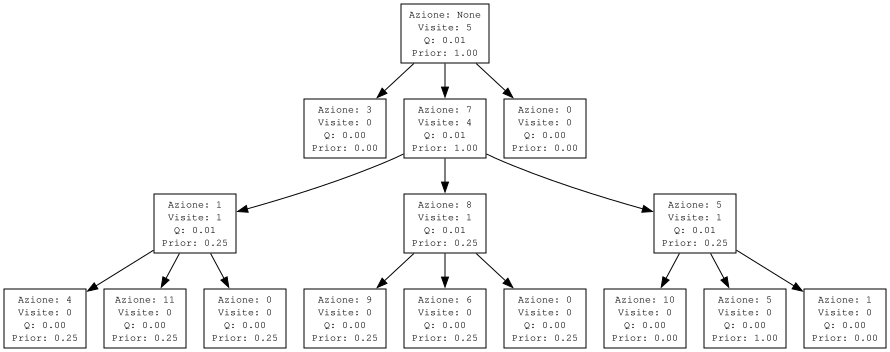

In [8]:
action = mcts.plot_search(gioco.state)

In [9]:
print("azione scelta: ", action)
print("ppl_iniziale: ", gioco.ppl)
gioco.do_action(action)
print("ppl dopo azione", gioco.ppl)
gioco.reset_game()

azione scelta:  7
ppl_iniziale:  66.278135003659
ppl dopo azione 74.47318366648517


tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], device='mps:0', dtype=torch.int8)

In [5]:
azioni_fatte = []
for i in range(100):
    print(i)
    action = mcts.search(gioco.state)
    azioni_fatte.append(action)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


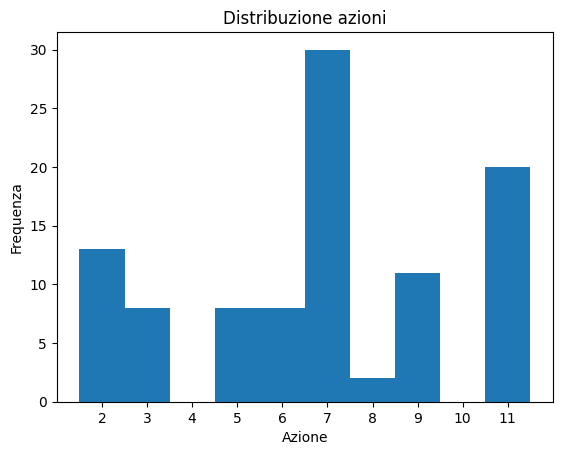

In [7]:
import numpy as np
import matplotlib.pyplot as plt

a_min = min(azioni_fatte)
a_max = max(azioni_fatte)

bins = np.arange(a_min, a_max + 2) - 0.5

plt.figure()
plt.hist(azioni_fatte, bins=bins)
plt.xticks(range(a_min, a_max + 1))   # mostrati tutti gli interi
plt.xlabel("Azione")
plt.ylabel("Frequenza")
plt.title("Distribuzione azioni")
plt.savefig("distribuzione_hard.png")
plt.show()

In [63]:
# migliore prima azione
gioco_nuovo = PruneGame(args)
stato_iniziale = gioco.initial_state

lista_ppl = []

for i in range(0,12):
    gioco_nuovo.do_action(i)
    lista_ppl.append((i, gioco_nuovo.ppl))
    gioco_nuovo.reset_game()
print(lista_ppl)

--> ppl iniziale:  66.278135003659
[(0, 742.6105844634161), (1, 2324.412529183591), (2, 82.0653991083652), (3, 82.94079665233679), (4, 75.98503139119295), (5, 87.25670683851982), (6, 84.62631721917997), (7, 74.47318366648517), (8, 94.03134797680305), (9, 82.72738706125959), (10, 109.65834475231867), (11, 79.2609452725811)]


In [73]:
print("minore lista azioni prima azione è: ", min(lista_ppl, key=lambda t: t[1]))

for i in sorted(lista_ppl, key=lambda t: t[1]):
    print(i)

minore lista azioni prima azione è:  (7, 74.47318366648517)
(7, 74.47318366648517)
(4, 75.98503139119295)
(11, 79.2609452725811)
(2, 82.0653991083652)
(9, 82.72738706125959)
(3, 82.94079665233679)
(6, 84.62631721917997)
(5, 87.25670683851982)
(8, 94.03134797680305)
(10, 109.65834475231867)
(0, 742.6105844634161)
(1, 2324.412529183591)
